## GPT-3 6.7B KV-cache mapping

This notebook uses the official `gpt3_6.7B_kv_cache.yaml` workload and adds a small compatibility hotfix so it also runs on older AccelForge builds that still raise `KeyError: 'Z'` on the TPU-v4-style fanout architecture.

In [143]:
from pathlib import Path

import accelforge as af

In [149]:
ARCH = Path("designs/arch.yaml")
WORKLOAD = Path("designs/gpt3_6.7B_kv_cache.yaml")

BATCH_SIZE = 1
N_TOKENS = 8192
N_NEW_TOKENS = 1
FUSE = False
MAPPER_JOBS = 1


def install_legacy_kv_cache_hotfix() -> bool:
    """Guard older AccelForge builds against the TPU-v4i KV-cache KeyError."""
    try:
        from accelforge.frontend.mapping import Spatial, Temporal
        import accelforge.mapper.FFM._make_pmappings.make_pmapping_templates.make_loops as make_loops
        import accelforge.mapper.FFM._make_pmappings.make_pmapping_templates.make_pmapping_templates as template_mod
    except ImportError:
        return False

    def patched_insert_spatial_loops(mapping, einsum, flattened_arch, intermediate_tensors):
        nodes_with_fanout = [node for node in flattened_arch if node.get_fanout() > 1]
        arch_node_names = [node.name for node in flattened_arch]
        tensor2fully_relevant_rank_vars = einsum.tensor2directly_indexing_rank_variables

        for node in nodes_with_fanout:
            insertion_point = make_loops._idx_below_lowest_tensor_holder_with_component_above_fanout(
                node,
                mapping,
                arch_node_names,
            )
            while insertion_point < len(mapping) and isinstance(mapping[insertion_point], Temporal):
                insertion_point += 1

            rank_variables = einsum.rank_variables
            unseen_tensors = intermediate_tensors - make_loops._tensors_seen_above_point(
                insertion_point,
                mapping,
            )
            for tensor_name in unseen_tensors:
                if tensor_name not in tensor2fully_relevant_rank_vars:
                    continue
                rank_variables &= tensor2fully_relevant_rank_vars[tensor_name]

            for fanout_dim in node.spatial:
                for rank_variable in sorted(rank_variables):
                    spatial = Spatial(
                        rank_variable=rank_variable,
                        name=fanout_dim.name,
                        component_object=node,
                        component=node.name,
                    )
                    if insertion_point == len(mapping):
                        mapping.append(spatial)
                    else:
                        mapping.insert(insertion_point, spatial)

    make_loops.insert_spatial_loops = patched_insert_spatial_loops
    template_mod.insert_spatial_loops = patched_insert_spatial_loops
    return True


hotfix_installed = install_legacy_kv_cache_hotfix()
af.set_n_parallel_jobs(MAPPER_JOBS)

print({
    "arch": str(ARCH),
    "workload": str(WORKLOAD),
    "mapper_jobs": MAPPER_JOBS,
    "legacy_hotfix_installed": hotfix_installed,
})

{'arch': 'designs/arch.yaml', 'workload': 'designs/gpt3_6.7B_kv_cache.yaml', 'mapper_jobs': 1, 'legacy_hotfix_installed': True}


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


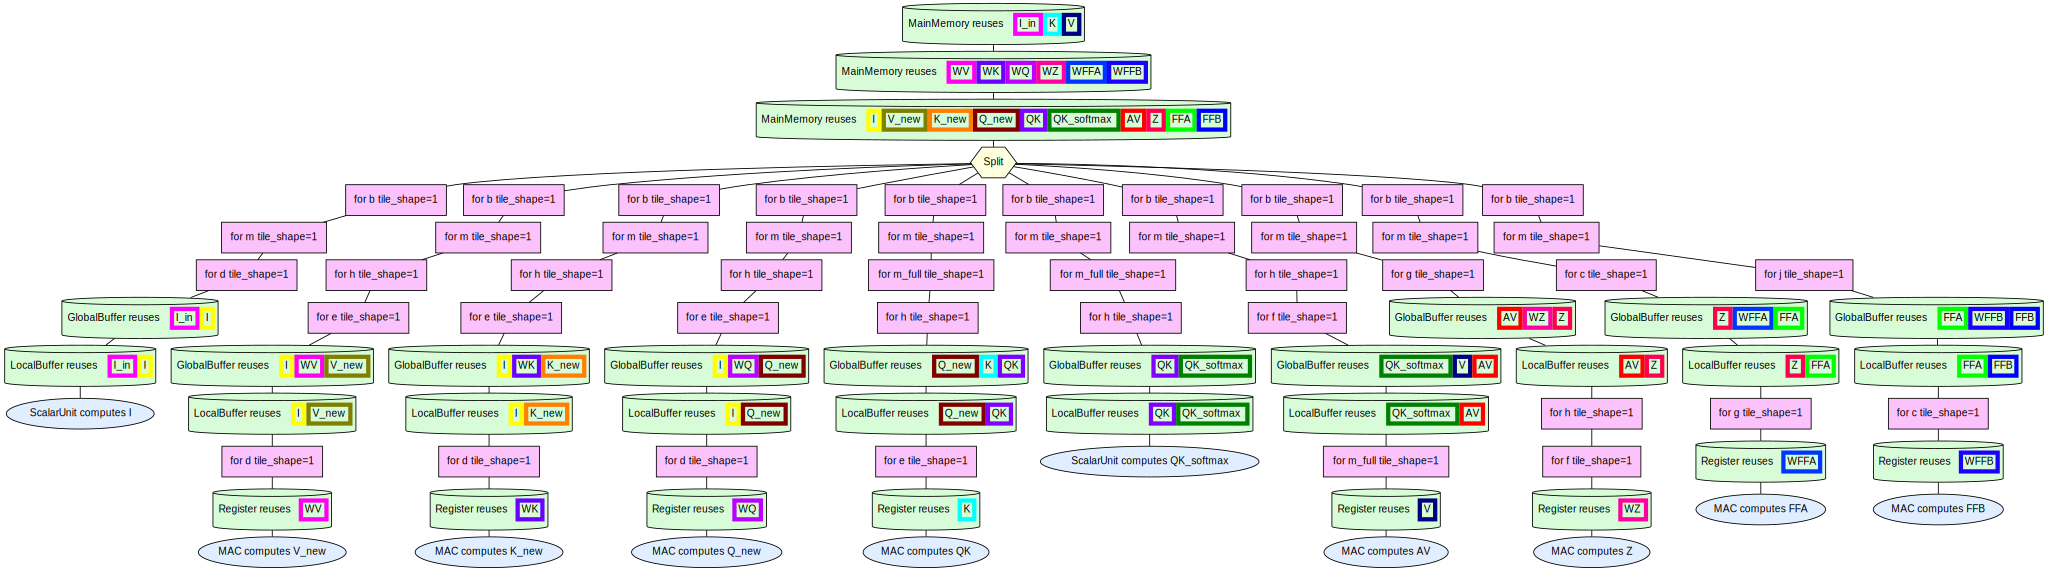

In [164]:
MAPPING = "designs/gpt3_6.7B_kv_cache_mapping.yaml"

spec = af.Spec.from_yaml(
    ARCH,
    WORKLOAD,
    MAPPING,
    jinja_parse_data={
        "BATCH_SIZE": BATCH_SIZE,
        "N_TOKENS": N_TOKENS,
        "N_NEW_TOKENS": N_NEW_TOKENS,
    },
)

result = spec.evaluate_mapping()

spec.mapping

In [163]:
result.latency()

416.4153253162448

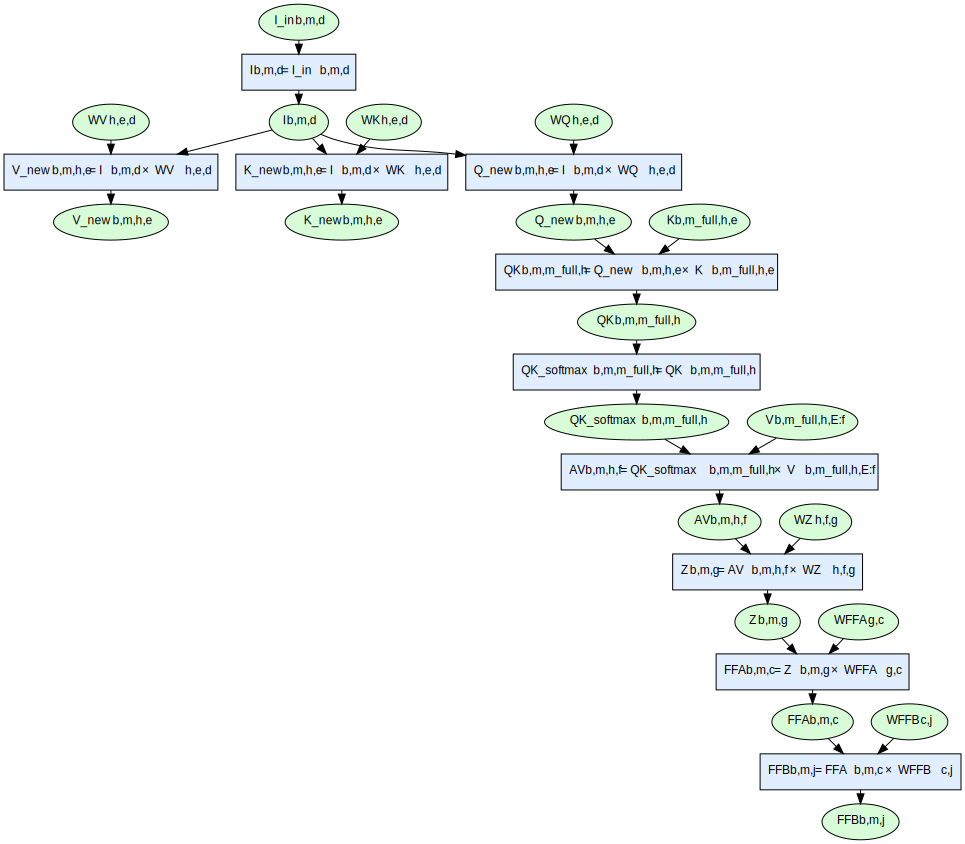

In [157]:
spec.workload

In [158]:


sort_columns = [
    column
    for column in ("Total<SEP>energy", "Total<SEP>latency")
    if column in result.data.columns
]
if sort_columns:
    result.data = result.data.sort_values(by=sort_columns, kind="mergesort").reset_index(drop=True)

best_mapping = result[0]

{
    "candidate_mappings": len(result),
    "energy": float(best_mapping.energy()),
    "latency": float(best_mapping.latency()),
}

{'candidate_mappings': 1, 'energy': 424.0, 'latency': 8.0}

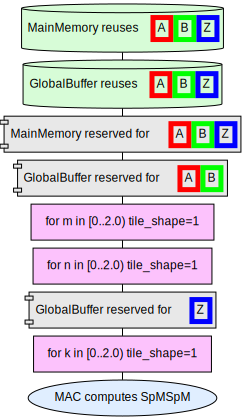

In [159]:
best_mapping.render()